In [45]:
import numpy as np
import pandas as pd
import string
import regex as re
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [34]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CS240-Project/WELFake_Dataset.csv',index_col=0)
print(data.info())
data = data.fillna('')

<class 'pandas.core.frame.DataFrame'>
Index: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   71576 non-null  object
 1   text    72095 non-null  object
 2   label   72134 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.2+ MB
None


In [36]:
def preprocess_data(data):
  ''' removing punctuations, deleting alphanumeric characters, converting uppercase characters to lowercase. '''

  data['title_text'] = data['title'] +' '+ data['text']

  data['title_text'] = data['title_text'].astype(str).str.lower()
  data['title_text'] = data['title_text'].str.replace(r'http\S+|www\S+', '', regex=True)

  data['title_text'] = data['title_text'].str.replace(r'#\w+', '', regex=True)
  data['title_text'] = data['title_text'].str.replace(r'@\w+', '', regex=True)
  data['title_text'] = data['title_text'].str.replace(r'\S*\*\S*', '', regex=True)
  data['title_text'] = data['title_text'].str.replace(r'\n', ' ', regex=True)
  data['title_text'] = data['title_text'].str.replace(r'[\n\r\t]', ' ', regex=True)

  # Remove weird non-printable hex characters like \x9c
  data['title_text'] = data['title_text'].apply(lambda x: re.sub(r'\p{P}+', '', x))
  data['title_text'] = data['title_text'].apply(lambda x: re.sub(r'[\x00-\x1f\x7f-\x9f]', '', x))
  data['title_text'] = data['title_text'].str.replace(r'\w*\d\w*', '', regex=True)

  data = data.drop(['title','text'],axis=1)
  return data

tmp_data = data.copy()
preprocessed_data = preprocess_data(tmp_data)

In [43]:
preprocessed_data = preprocessed_data[['title_text','label']]
preprocessed_data.head()

,title_text,label
0,law enforcement on high alert following threat...,1
1,did they post their votes for hillary already,1
2,unbelievable obamas attorney general says most...,1
3,bobby jindal raised hindu uses story of christ...,0
4,satan russia unvelis an image of its terrifyi...,1


In [44]:
preprocessed_data.to_csv('preprocessed_data.csv',index=False)

In [46]:
'''splitting the data into test and train '''
train_data, test_data = train_test_split(preprocessed_data, test_size=0.2, random_state=42)

In [50]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14427 entries, 61370 to 64614
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   title_text  14427 non-null  object
 1   label       14427 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 338.1+ KB


In [53]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [61]:
fake_titles = ' '.join(test_data[test_data['label'] == 0]['title_text'])
real_titles = ' '.join(test_data[test_data['label'] == 1]['title_text'])
fake_wordcloud = WordCloud(
    background_color='black',
    max_words=300,
    width=800,
    height=400,
).generate(fake_titles)
real_wordcloud = WordCloud(
    background_color='black',
    max_words=300,
    width=800,
    height=400,
).generate(real_titles)

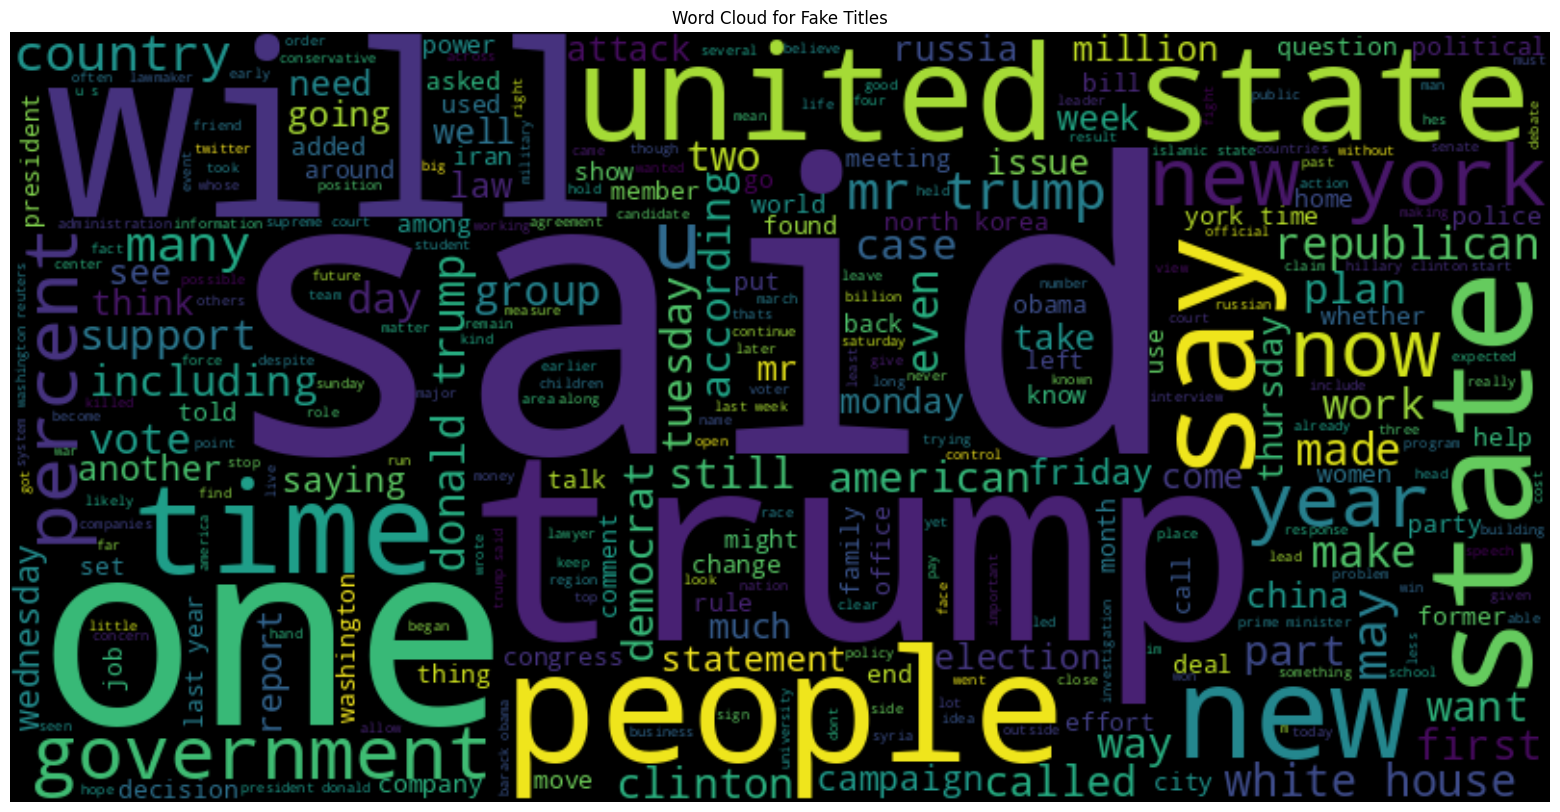

In [62]:
plt.figure(figsize=(20, 10))
plt.imshow(fake_wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Fake Titles')
plt.axis("off")
plt.show()

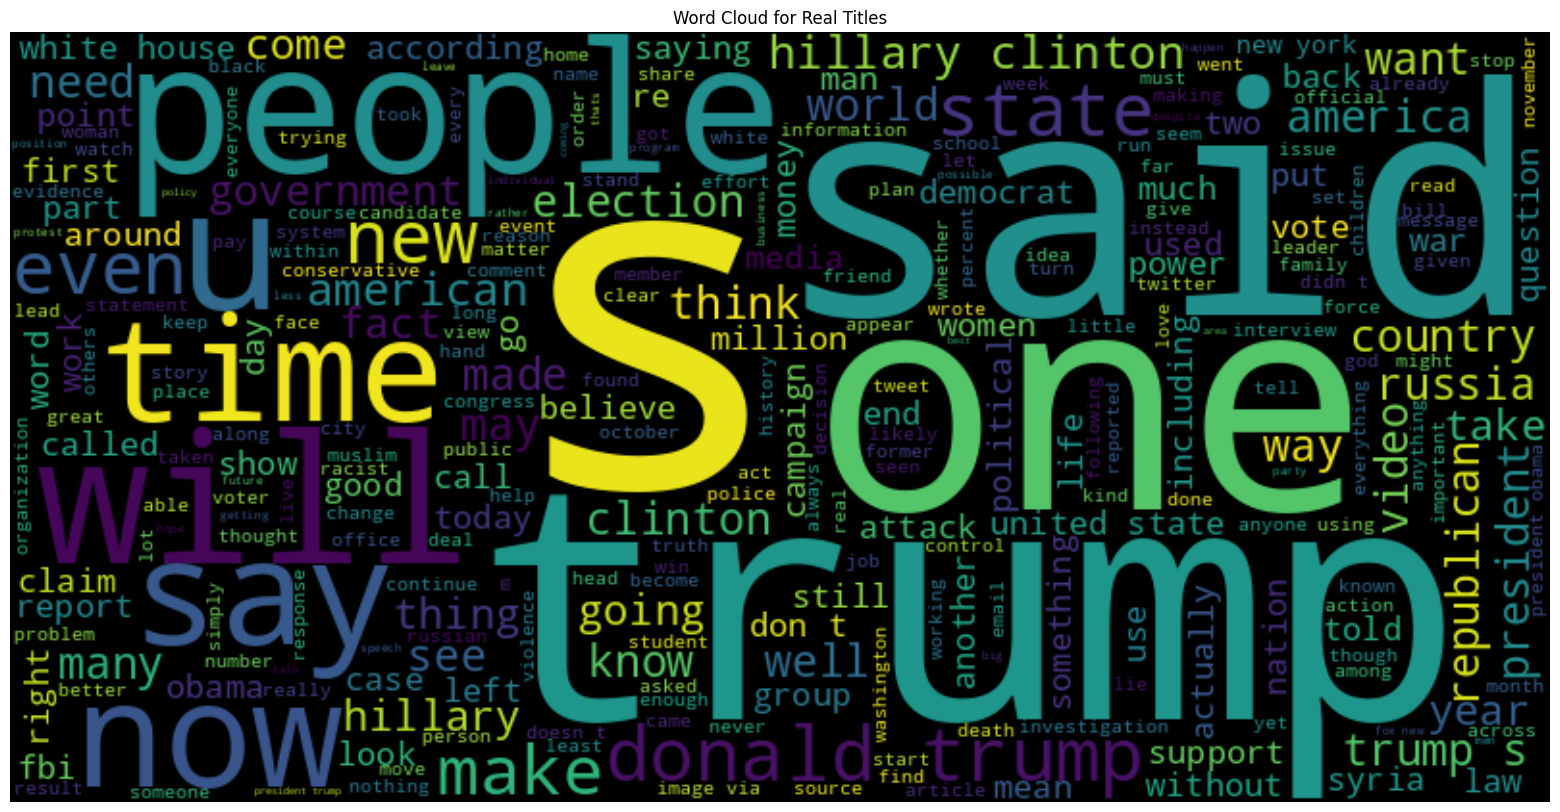

In [63]:
plt.figure(figsize=(20, 10))
plt.imshow(real_wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Real Titles')
plt.axis("off")
plt.show()